In [ ]:
#!pip install pandas astroquery astropy numpy matplotlib scipy PyAstronomy
#Starting with the imports for all the different functions that will be used in this script and defining a defualt folder for saving plots
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
from scipy.optimize import curve_fit
from astropy.timeseries import LombScargle
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from PyAstronomy.pyTiming import pyPDM
import os

#Default folder for saving plots
default_folder = "plots"  

In [ ]:
#Now importing the mean and epoch photomotry, the gaia input, and the sys module to add the path to the gaiadr3_analysis folder
import gaiadr3_analysis.gaia_input as gi
import gaiadr3_analysis.mean_photometry as mphot
import gaiadr3_analysis.epoch_photometry as ephot

In [ ]:
#quering the Mean photometry data for the Gaia DR3 database for the stars in the MeMis survey
source_ids = (
4146594906281066368, 418001477279154304, 181233674136088960,
3211026372078082048, 3220757015623151616, 3017360348171372672,
3209634905754969856, 3017364063330718080, 3017367396223983616,
3216486478101981056, 3224479171721217280, 3217413606922372992,
3326710010525962624, 2922367976673391232, 5517239366958299776,
5513811055342280448, 817013387993056640, 5338490937045044096,
5336220823491735680, 3667302325846472320, 6116497702589633152,
6005290206037557760, 6044420729667868928, 4371780385208211584,
6730764715540788352, 2032810465079954944, 2059130368252069888,
2270245431209611776, 2272185759996420992, 1796736625538995072,
3131334452194616192
)

id_list = ", ".join(str(s) for s in source_ids)

adql = f"""
SELECT source_id, designation, ra, dec, parallax,
pmra, pmdec, phot_g_mean_mag, phot_bp_mean_mag,
phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE source_id IN ({id_list})
"""

df = gi.query_by_adql(adql)
print(f"Retrieved {len(df)} stars")
df.head()

In [ ]:
#Calling and saving all plots and functions from the MeMis survey data to a folder called plots in the mean photometry category. 

mphot.ra_vs_dec(df, save_plot=True, save_title="ra_vs_dec1", save_folder="presentation_plots",plot_title="RA vs Dec MiMes Survey Data")
mphot.pmra_vs_pmdec(df, save_plot=True, save_title="pmra_vs_pmdec1", save_folder="presentation_plots",plot_title="PMRA vs PMDEC MiMes Survey Data")
mphot.plot_hr_diagram(df, save_plot=True, save_title="hr_diagram1", save_folder="presentation_plots",plot_title="HR Diagram MiMes Survey Data")
mphot.hist(dists=df['parallax'], parallax=True, save_plot=True, save_title="hist1", save_folder="presentation_plots",plot_title="Histogram MiMes Survey Data")
mphot.fittedHist(dists=df['parallax'], parallax=True, save_plot=True, save_title="fitted_hist1", save_folder="presentation_plots",plot_title="Fitted Histogram MiMes Survey Data")

Best period = 0.1012145748987858 days
Plot saved as plots\pdm_plot1.pdf


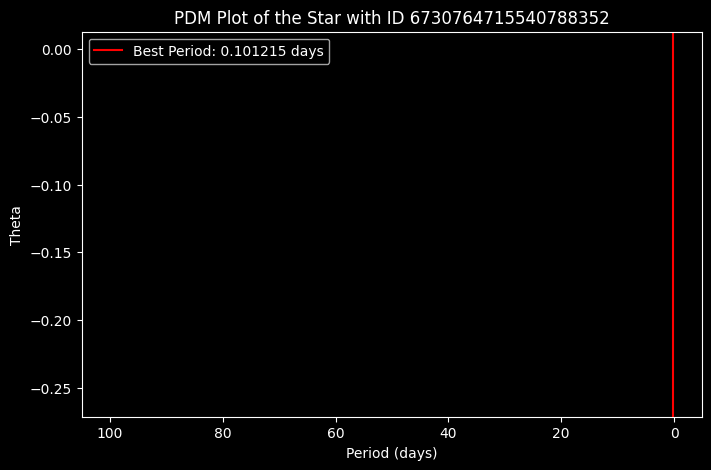

,frequency,theta
0,0.010,-0.058588
1,0.011,-0.016701
2,0.012,-0.124276
3,0.013,-0.031407
4,0.014,-0.133533
...,...,...
9986,9.996,-0.037568
9987,9.997,-0.038086
9988,9.998,-0.006582
9989,9.999,-0.162256


In [10]:
#Calling and saving all plots and functions from the MeMis survey data to a folder called plots in the epoch photometry category.

#Using a data link and retrieving the epoch photometry data from the star with ID 6730764715540788352 from the MeMis survey

df_datalink = gi.query_by_datalink(6730764715540788352)[6730764715540788352]

ephot.lightcurve(df_datalink, save_plot=True, save_title="light_curve1", save_folder="presentation_plots",plot_title="Flux vs Time of the Star with ID 6730764715540788352")
ephot.lomb_scargle(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, save_plot = True, plot_title="Lomb-Scargle Periodogram of the Star with ID 6730764715540788352", save_title="ls_plot1", save_folder="presentation_plots")
ephot.pdm(df_datalink['g_transit_time'], df_datalink['g_transit_mag'], plot = True, save_plot = True, plot_title="PDM Plot of the Star with ID 6730764715540788352", save_title="pdm_plot1", save_folder="presentation_plots")